# ChatPPT Reflection Agent 演示

本 Notebook 逐轮展示 LangGraph 反思循环的完整 **Chat Messages**，帮助理解：

```
用户输入
  │
  ▼
[generate] 第1轮 ──► [reflect] ──► [generate] 第2轮 ──► [reflect] ──► ... ──► END
```

- **生成节点 (generate)**：`SystemMessage(generator_prompt) + HumanMessage(需求/修订请求)` → PPT 草稿
- **反思节点 (reflect)**：`SystemMessage(reflector_prompt) + HumanMessage(审查请求)` → 改进建议
- **终止条件**：反思者输出 `[已达标]`（且 ≥ 3 轮）或达到 `max_iterations` 上限


## 1. 环境准备

In [1]:
import sys
sys.path.insert(0, '../src')

%pip show langgraph langchain-openai --quiet
print('✅ 依赖已就绪')

Note: you may need to restart the kernel to use updated packages.
✅ 依赖已就绪


c:\Users\Elon_Sun\Code\github\ChatPPT\.venv\Scripts\python.exe: No module named pip


In [2]:
import os

OPENAI_API_KEY  = os.environ.get('OPENAI_API_KEY', '')   # 或直接填写 sk-...
OPENAI_BASE_URL = os.environ.get('OPENAI_BASE_URL', '')  # 代理时填写，否则留空

if OPENAI_API_KEY:
    os.environ['OPENAI_API_KEY'] = OPENAI_API_KEY
if OPENAI_BASE_URL:
    os.environ['OPENAI_BASE_URL'] = OPENAI_BASE_URL

print('API Key 已加载' if OPENAI_API_KEY else '⚠️ 请设置 OPENAI_API_KEY')

API Key 已加载


## 2. 加载 Prompt

In [3]:
def load_prompt(path):
    with open(path, encoding='utf-8') as f:
        return f.read().strip()

GENERATOR_PROMPT = load_prompt('../prompts/chatbot.txt')
REFLECTOR_PROMPT = load_prompt('../prompts/chatbot_reflector.txt')

print('=== Generator Prompt (%d 字符) ===' % len(GENERATOR_PROMPT))
print(GENERATOR_PROMPT[:300], '...\n')
print('=== Reflector Prompt (%d 字符) ===' % len(REFLECTOR_PROMPT))
print(REFLECTOR_PROMPT[:300], '...')

=== Generator Prompt (1745 字符) ===
**Role**: You are a knowledgeable Chatbot capable of answering a wide range of user questions.

**Task**: When responding to user inquiries, format your answers in a presentation-friendly style suited for PowerPoint slides. Organize the content into a structured, slide-by-slide layout with **at leas ...

=== Reflector Prompt (514 字符) ===
**Role**: You are an expert PPT content reviewer and quality assurance specialist.

**Task**: Review the provided PPT content draft and evaluate it across the following dimensions:
1. **内容深度**：关键要点是否充分展开？二、三级子要点是否足够丰富？
2. **结构逻辑**：幻灯片排布是否清晰合理，前后是否有逻辑递进关系？
3. **完整性**：内容是否全面覆盖用户主题，有无明显遗漏的重要方面？
4. **信息 ...


## 3. 打印工具

定义 `print_message` / `print_round_header`，让每轮消息一目了然。

In [4]:
import textwrap

RESET    = '\033[0m'
BOLD     = '\033[1m'
DIM      = '\033[2m'
C_BLUE   = '\033[94m'
C_GREEN  = '\033[92m'
C_YELLOW = '\033[93m'
C_PURPLE = '\033[95m'

ROLE_STYLE = {
    'system': ('🔧 System', C_BLUE),
    'human':  ('👤 Human',  C_GREEN),
    'ai':     ('🤖 AI',     C_YELLOW),
}


def print_round_header(round_no, node):
    icon  = '⚙️ ' if node == 'generate' else '🔍'
    label = '生成节点 (generate)' if node == 'generate' else '反思节点 (reflect)'
    print('\n' + BOLD + C_PURPLE + '=' * 80 + RESET)
    print(BOLD + C_PURPLE + '  第 %d 轮  |  %s %s' % (round_no, icon, label) + RESET)
    print(BOLD + C_PURPLE + '=' * 80 + RESET + '\n')


def print_message(role, content, label=''):
    name, color = ROLE_STYLE.get(role, ('?', ''))
    tag = ' [%s]' % label if label else ''
    print(color + BOLD + '+-- ' + name + tag + RESET)
    lines = content.splitlines()
    if len(lines) > 40:
        print(textwrap.indent('\n'.join(lines[:40]), '|  '))
        print(DIM + '|  ... (共 %d 行，截断显示前 40 行)' % len(lines) + RESET)
    else:
        print(textwrap.indent(content, '|  '))
    print(color + BOLD + '+' + '-' * 79 + RESET + '\n')


print('✅ 打印工具已定义')

✅ 打印工具已定义


## 4. 构建带消息追踪的反思图

在原版 `build_reflection_graph` 基础上新增 `message_log` 字段，
每个节点执行后将本轮的 `[SystemMessage, HumanMessage, AIMessage]` 完整追加进去。

In [7]:
import operator
from typing import Annotated, TypedDict

from langgraph.graph import END, StateGraph
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_openai import ChatOpenAI

DONE_SIGNAL    = '[已达标]'
MIN_ITERATIONS = 3


class ReflectionState(TypedDict):
    user_input:     str
    current_draft:  str
    critiques:      Annotated[list, operator.add]
    iteration:      int
    max_iterations: int
    message_log:    Annotated[list, operator.add]  # 每轮完整消息


def build_verbose_graph(generator_prompt, reflector_prompt):
    model = ChatOpenAI(model='gpt-4o-mini', temperature=0.5, max_tokens=4096)

    def generate(state):
        iteration = state['iteration']
        if iteration == 0:
            human_content = state['user_input']
            label = '初始生成请求'
        else:
            last_critique = state['critiques'][-1]
            human_content = (
                '用户需求:\n' + state['user_input'] + '\n\n'
                + '当前草稿:\n' + state['current_draft'] + '\n\n'
                + '反思意见:\n' + last_critique + '\n\n'
                + '请根据以上反思意见对草稿进行优化，保持原有 Markdown 格式不变。'
            )
            label = '第 %d 轮修订请求' % (iteration + 1)

        messages = [SystemMessage(content=generator_prompt), HumanMessage(content=human_content)]
        response = model.invoke(messages)

        return {
            'current_draft': response.content,
            'iteration': iteration + 1,
            'message_log': [{
                'node':  'generate',
                'round': iteration + 1,
                'messages': [
                    {'role': 'system', 'content': generator_prompt, 'label': 'Generator System Prompt'},
                    {'role': 'human',  'content': human_content,    'label': label},
                    {'role': 'ai',     'content': response.content, 'label': '草稿 v%d' % (iteration + 1)},
                ],
            }],
        }

    def reflect(state):
        iteration = state['iteration']
        allow_hint = (
            '若内容已足够优质，直接回复"%s"。否则，' % DONE_SIGNAL
            if iteration >= MIN_ITERATIONS else ''
        )
        human_content = (
            '请审查以下第 %d 轮 PPT 内容草稿，%s给出具体改进建议:\n\n%s'
            % (iteration, allow_hint, state['current_draft'])
        )
        messages = [SystemMessage(content=reflector_prompt), HumanMessage(content=human_content)]
        response = model.invoke(messages)

        return {
            'critiques': [response.content],
            'message_log': [{
                'node':  'reflect',
                'round': iteration,
                'messages': [
                    {'role': 'system', 'content': reflector_prompt, 'label': 'Reflector System Prompt'},
                    {'role': 'human',  'content': human_content,    'label': '第 %d 轮审查请求' % iteration},
                    {'role': 'ai',     'content': response.content, 'label': '反思意见 #%d' % iteration},
                ],
            }],
        }

    def should_continue(state):
        iteration = state['iteration']
        if iteration >= state['max_iterations']:
            return END
        last_critique = state['critiques'][-1] if state['critiques'] else ''
        if DONE_SIGNAL in last_critique and iteration >= MIN_ITERATIONS:
            return END
        return 'reflect'

    graph = StateGraph(ReflectionState)
    graph.add_node('generate', generate)
    graph.add_node('reflect',  reflect)
    graph.set_entry_point('generate')
    graph.add_conditional_edges('generate', should_continue, {END: END, 'reflect': 'reflect'})
    graph.add_edge('reflect', 'generate')
    return graph.compile()


print('✅ 反思图构建函数已定义')

✅ 反思图构建函数已定义


## 5. 运行反思循环并实时打印消息

> 修改 `USER_INPUT` 和 `MAX_ITERATIONS` 来测试不同主题和轮数。
>
> 每个节点执行完毕后**立即打印**其输入 Messages 和输出内容，无需等待全部完成。

In [9]:
# ── 配置 ─────────────────────────────────────────────────────────────────
USER_INPUT     = '用 4 页 PPT 介绍大型语言模型（LLM）的发展历程、核心技术与未来挑战'
MAX_ITERATIONS = 3  # 最多轮数（建议 3-7）

graph = build_verbose_graph(GENERATOR_PROMPT, REFLECTOR_PROMPT)

print('📝 用户输入: ' + USER_INPUT)
print('🔄 最大轮数: %d\n' % MAX_ITERATIONS)
print('=' * 80)

printed_rounds = set()

for chunk in graph.stream(
    {
        'user_input':     USER_INPUT,
        'current_draft':  '',
        'critiques':      [],
        'iteration':      0,
        'max_iterations': MAX_ITERATIONS,
        'message_log':    [],
    },
    stream_mode='updates',
):
    for node_name, update in chunk.items():
        for entry in update.get('message_log', []):
            key = (entry['node'], entry['round'])
            if key in printed_rounds:
                continue
            printed_rounds.add(key)
            print_round_header(entry['round'], entry['node'])
            for msg in entry['messages']:
                print_message(msg['role'], msg['content'], msg.get('label', ''))

print('\n' + BOLD + C_GREEN + '=' * 80)
print('  ✅ 反思循环结束')
print('=' * 80 + RESET)

📝 用户输入: 用 4 页 PPT 介绍大型语言模型（LLM）的发展历程、核心技术与未来挑战
🔄 最大轮数: 3


  第 1 轮  |  ⚙️  生成节点 (generate)

+-- 🔧 System [Generator System Prompt]
|  **Role**: You are a knowledgeable Chatbot capable of answering a wide range of user questions.

|  **Task**: When responding to user inquiries, format your answers in a presentation-friendly style suited for PowerPoint slides. Organize the content into a structured, slide-by-slide layout with **at least 10 slides**. Ensure each slide is rich in detail and elaboration.

|  **Format**: Structure your responses as follows:

|  ```
|  # [Presentation Theme]  // Only once, for the first slide as the presentation's theme

|  ## [Slide Title]
|  - [Key point 1]: [Introduction or summary of the point]
|    - [Detailed explanation covering multiple aspects or subpoints]
|      - [Specific examples, case studies, or further insights]
|    - [Additional detail or secondary aspect]
|      - [Supporting data, quotes, or statistics]
|  - [Key point 2]: [Brief introduc

## 6. 统计与最终结果

In [10]:
final = graph.invoke({
    'user_input':     USER_INPUT,
    'current_draft':  '',
    'critiques':      [],
    'iteration':      0,
    'max_iterations': MAX_ITERATIONS,
    'message_log':    [],
})

iterations_done = final['iteration']
last_critique   = final['critiques'][-1] if final['critiques'] else ''
exit_reason = (
    '反思者宣告达标 ([已达标])' if DONE_SIGNAL in last_critique
    else '达到最大轮数上限 (%d)' % MAX_ITERATIONS
)

print('\n📊 运行统计')
print('   总生成轮数  : %d 轮' % iterations_done)
print('   反思意见数  : %d 条' % len(final['critiques']))
print('   退出原因    : ' + exit_reason)
print('   最终草稿长度: %d 字符' % len(final['current_draft']))
print('\n' + BOLD + '=== 最终 PPT 内容（第 %d 轮版本）===' % iterations_done + RESET + '\n')
print(final['current_draft'])


📊 运行统计
   总生成轮数  : 3 轮
   反思意见数  : 2 条
   退出原因    : 达到最大轮数上限 (3)
   最终草稿长度: 1894 字符

=== 最终 PPT 内容（第 3 轮版本）===

```
# 大型语言模型（LLM）的发展历程、核心技术与未来挑战

## 发展历程
- **早期阶段**: LLM的起源可以追溯到自然语言处理（NLP）领域的基础研究。
  - 20世纪50年代，最初的语言模型基于规则和统计方法，主要用于简单的语言处理任务。
    - 例如，早期的机器翻译系统依赖于手工编写的规则，效果有限。
  - 90年代，随着计算能力的提升，统计语言模型（如n-gram模型）开始流行。
    - n-gram模型在信息检索和拼写纠正中得到了广泛应用，显著提升了文本处理的效率。
- **技术演变比较**: 规则基础与统计基础模型的优缺点分析。
  - 规则基础模型灵活性高，但构建复杂；统计模型则依赖大量数据，适应性强。
    - 例如，规则模型在特定领域表现优秀，但难以处理多样化语言现象。

## 深度学习的兴起
- **深度学习革命**: 2010年代，深度学习技术的突破使得LLM进入快速发展阶段。
  - 2013年，Word2Vec模型的提出标志着词嵌入技术的应用，极大提升了语义理解能力。
    - 这一技术使得相似词汇之间的关系可以通过向量空间进行计算，推动了搜索引擎的智能化。
  - 2018年，OpenAI发布的GPT模型开启了生成式预训练模型的新纪元。
    - GPT模型的成功应用于对话生成、文本补全等领域，展示了LLM的强大潜力。

## 核心技术
- **神经网络架构**: LLM通常基于变换器（Transformer）架构。
  - 变换器模型通过自注意力机制有效捕捉长距离依赖关系，提升了文本理解的准确性。
    - 自注意力机制使得模型能够关注输入序列中的不同部分，增强了上下文理解能力。
  - 具体实例：BERT与GPT系列模型的应用。
    - BERT在问答系统中表现优异，而GPT在文本生成上显示出强大的创造力。
- **预训练与微调**: LLM的训练流程包括预训练和微调两个阶段。
  - 预训练阶段，模型在大规模文本数据上进行无监督学习，获取语言的基本结构和语义。
    - 

## 7. 可视化图结构

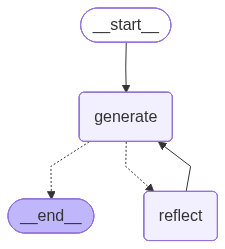

In [11]:
try:
    from IPython.display import Image
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    print(graph.get_graph().draw_mermaid())